<a href="https://colab.research.google.com/github/Borracheira/gravitacional-wave/blob/main/Chirp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chirp**

O chirp é a assinatura característica dos sinais de ondas gravitacionais produzidos pela coalescência de sistemas binários compactos, como pares de buracos negros ou estrelas de nêutrons. Esse tipo de sinal é caracterizado pelo aumento simultâneo da frequência e da amplitude à medida que os dois corpos espiralam um em direção ao outro devido à emissão de ondas gravitacionais. Esse comportamento ocorre porque, conforme a distância entre os objetos diminui, a velocidade orbital aumenta, resultando na emissão de ondas com frequências cada vez mais elevadas, até o instante da fusão. Após esse momento, o sinal entra na fase de ringdown, na qual o objeto remanescente perde energia até atingir um estado estável. O formato de chirp é uma das principais assinaturas utilizadas na detecção e caracterização de ondas gravitacionais, permitindo estimar parâmetros físicos do sistema, como as massas dos objetos, o momento da coalescência e a distância até a fonte.

### Exemplo: Soma de Três Ondas Senoidais e sua Representação na Frequência

In [ ]:
# 1. Definir parâmetros para o sinal
Fs_new = 500  # Frequência de amostragem em Hz
T_new = 2     # Duração total do sinal em segundos
N_new = int(Fs_new * T_new) # Número total de amostras

t_new = np.linspace(0, T_new, N_new, endpoint=False) # Vetor de tempo
dt_new = t_new[1] - t_new[0] # Intervalo de tempo entre as amostras

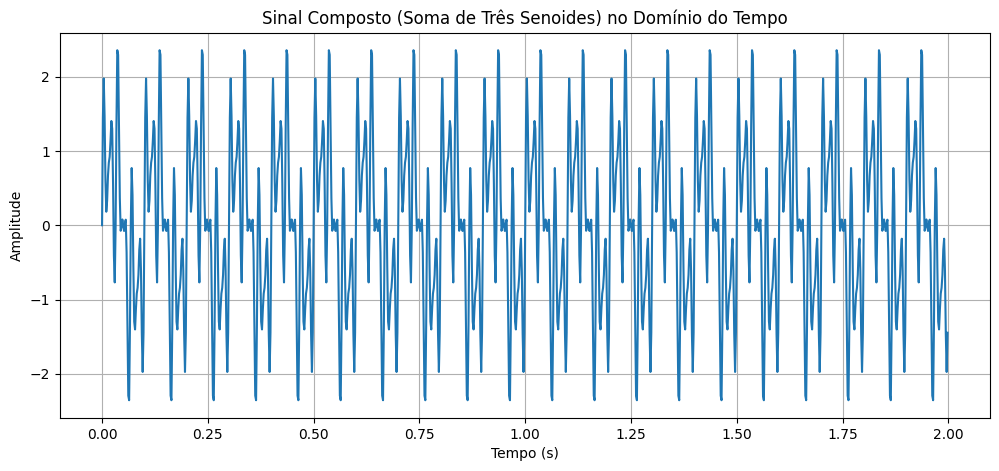

In [ ]:
# 2. Criar três ondas senoidais com diferentes frequências e amplitudes
f1 = 10 # Hz
f2 = 30 # Hz
f3 = 60 # Hz
f4=  90 #Hz

A1 = 1.0 # Amplitude da primeira senoide
A2 = 0.5 # Amplitude da segunda senoide
A3 = 1.0 # Amplitude da terceira senoide
A4 = 0.5 # Amplitude da quarta senoide

# Criar as ondas senoidais

sine1 = A1 * np.sin(2 * np.pi * f1 * t_new)
sine2 = A2 * np.sin(2 * np.pi * f2 * t_new)
sine3 = A3 * np.sin(2 * np.pi * f3 * t_new)
sine4 = A4 * np.sin(2 * np.pi * f4 * t_new)

# 3. Somar as três ondas senoidais
y_sum_sines = sine1 + sine2 + sine3 + sine4

# Plotar o sinal composto no domínio do tempo
plt.figure(figsize=(12, 5))
plt.plot(t_new, y_sum_sines)
plt.title('Sinal Composto (Soma de Três Senoides) no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [ ]:
# 4. Realizar a FFT no sinal composto
Y_sum_sines_fft = fft(y_sum_sines)

In [ ]:
# 5. Calcular as frequências correspondentes ao output da FFT
x_freq = fftfreq(N_new, dt_new)

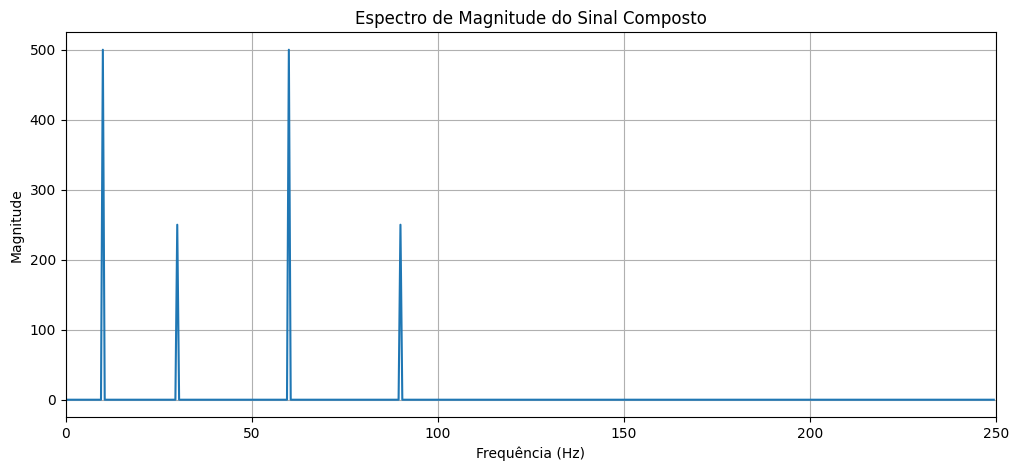

In [ ]:
# 6. Plotar o espectro de magnitude da FFT (apenas a parte positiva das frequências)
plt.figure(figsize=(12, 5))
plt.plot(x_freq[:N_new // 2], np.abs(Y_sum_sines_fft[:N_new // 2]))
plt.title('Espectro de Magnitude do Sinal Composto')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, Fs_new / 2) # Limitar o eixo x até a frequência de Nyquist
plt.show()

### Exemplo: Sinal Chirp Linear e sua Representação na Frequência

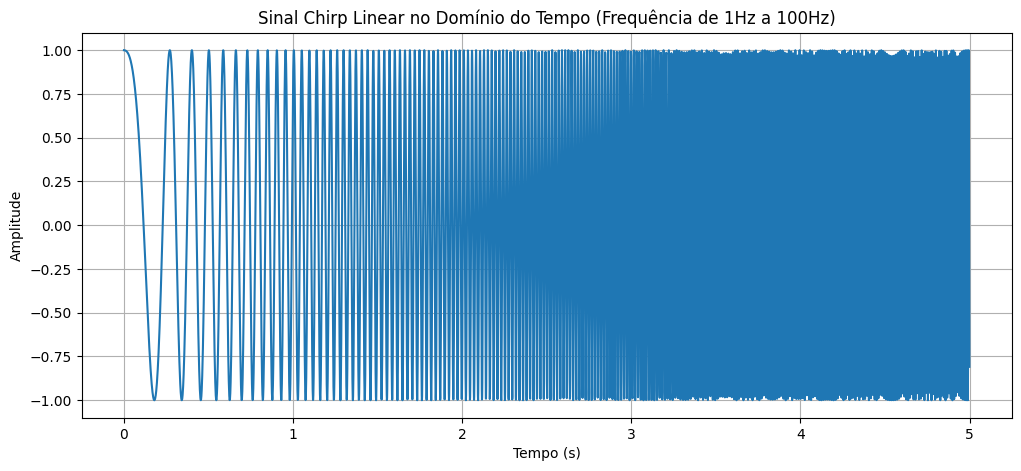

In [ ]:
from scipy.signal import chirp

# 1. Definir parâmetros para o sinal chirp linear
Fs_chirp = 1000 # Frequência de amostragem em Hz
T_chirp = 5     # Duração total do sinal em segundos
f0_chirp = 1   # Frequência inicial em Hz
f1_chirp = 100  # Frequência final em Hz

N_chirp = int(Fs_chirp * T_chirp) # Número total de amostras
t_chirp = np.linspace(0, T_chirp, N_chirp, endpoint=False) # Vetor de tempo
dt_chirp = t_chirp[1] - t_chirp[0]

# 2. Gerar o sinal chirp linear
y_chirp = chirp(t_chirp, f0=f0_chirp, f1=f1_chirp, t1=T_chirp, method='linear')

# Plotar o sinal chirp no domínio do tempo
plt.figure(figsize=(12, 5))
plt.plot(t_chirp, y_chirp)
plt.title('Sinal Chirp Linear no Domínio do Tempo (Frequência de ' + str(f0_chirp) + 'Hz a ' + str(f1_chirp) + 'Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

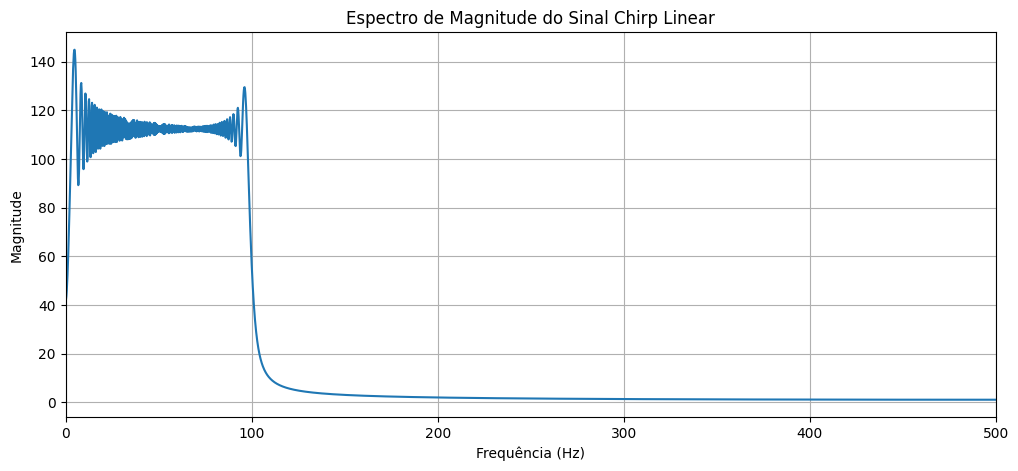

In [ ]:
# 3. Realizar a FFT no sinal chirp
Y_chirp_fft = fft(y_chirp)

# 4. Calcular as frequências correspondentes ao output da FFT
x_chirp_freq = fftfreq(N_chirp, dt_chirp)

# 5. Plotar o espectro de magnitude da FFT
plt.figure(figsize=(12, 5))
plt.plot(x_chirp_freq[:N_chirp // 2], np.abs(Y_chirp_fft[:N_chirp // 2]))
plt.title('Espectro de Magnitude do Sinal Chirp Linear')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, Fs_chirp / 2) # Limitar o eixo x até a frequência de Nyquist
plt.show()

### Exemplo: Sinal Chirp Quadrático e sua Representação na Frequência

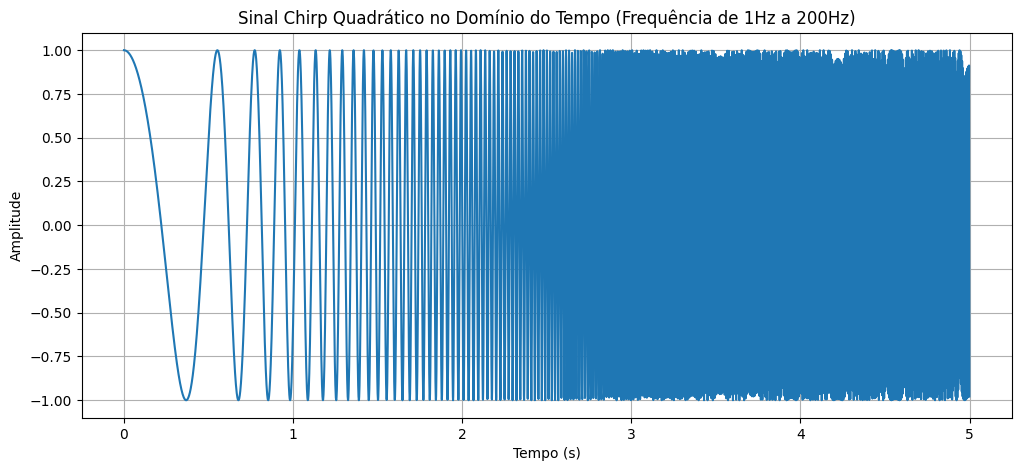

In [ ]:
from scipy.signal import chirp

# 1. Definir parâmetros para o sinal chirp quadrático
Fs_qchirp = 1000 # Frequência de amostragem em Hz
T_qchirp = 5     # Duração total do sinal em segundos
f0_qchirp = 1   # Frequência inicial em Hz
f1_qchirp = 200  # Frequência final em Hz

N_qchirp = int(Fs_qchirp * T_qchirp) # Número total de amostras
t_qchirp = np.linspace(0, T_qchirp, N_qchirp, endpoint=False) # Vetor de tempo
dt_qchirp = t_qchirp[1] - t_qchirp[0]

# 2. Gerar o sinal chirp quadrático
y_qchirp = chirp(t_qchirp, f0=f0_qchirp, f1=f1_qchirp, t1=T_qchirp, method='quadratic')

# Plotar o sinal chirp quadrático no domínio do tempo
plt.figure(figsize=(12, 5))
plt.plot(t_qchirp, y_qchirp)
plt.title('Sinal Chirp Quadrático no Domínio do Tempo (Frequência de ' + str(f0_qchirp) + 'Hz a ' + str(f1_qchirp) + 'Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

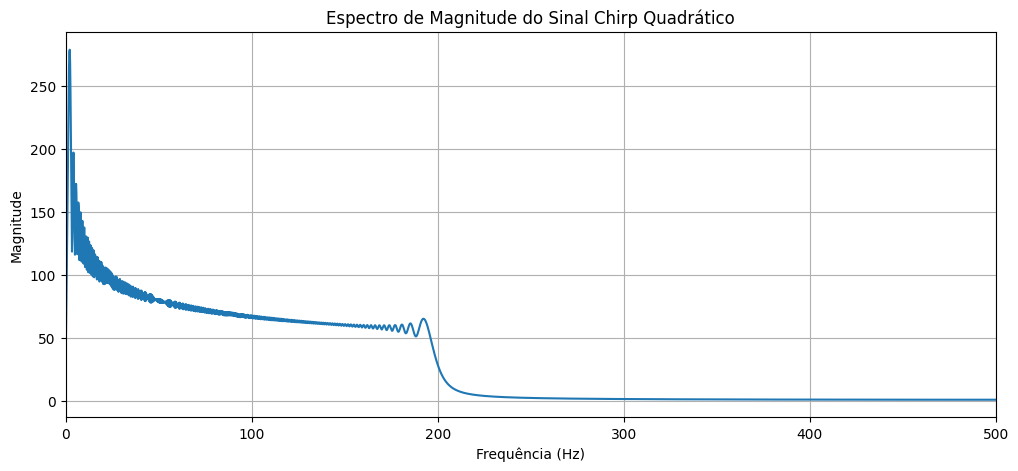

In [ ]:
# 3. Realizar a FFT no sinal chirp quadrático
Y_qchirp_fft = fft(y_qchirp)

# 4. Calcular as frequências correspondentes ao output da FFT
x_qchirp_freq = fftfreq(N_qchirp, dt_qchirp)

# 5. Plotar o espectro de magnitude da FFT
plt.figure(figsize=(12, 5))
plt.plot(x_qchirp_freq[:N_qchirp // 2], np.abs(Y_qchirp_fft[:N_qchirp // 2]))
plt.title('Espectro de Magnitude do Sinal Chirp Quadrático')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, Fs_qchirp / 2) # Limitar o eixo x até a frequência de Nyquist
plt.show()

### Exemplo: Soma de um Sinal Chirp Linear e um Sinal Chirp Quadrático e sua Representação na Frequência

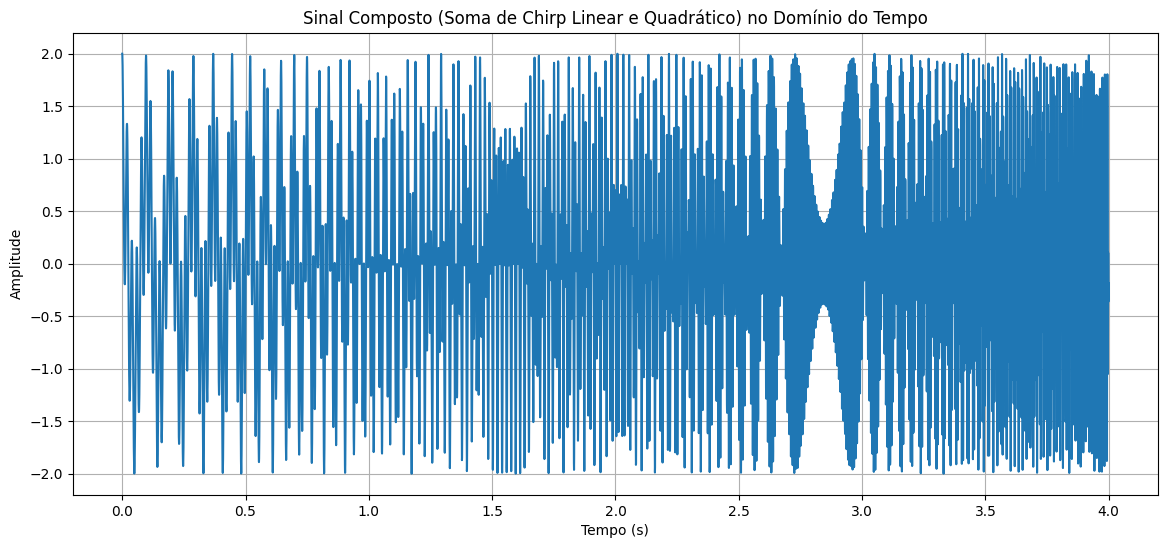

In [ ]:
from scipy.signal import chirp

# 1. Definir parâmetros para os dois sinais chirp
Fs_sum = 2000   # Frequência de amostragem em Hz
T_sum = 4       # Duração total do sinal em segundos
N_sum = int(Fs_sum * T_sum) # Número total de amostras

t_sum = np.linspace(0, T_sum, N_sum, endpoint=False) # Vetor de tempo
dt_sum = t_sum[1] - t_sum[0]

# Parâmetros para o Chirp Linear
f0_lin = 50     # Frequência inicial linear em Hz
f1_lin = 200    # Frequência final linear em Hz

# Parâmetros para o Chirp Quadrático
f0_quad = 10    # Frequência inicial quadrática em Hz
f1_quad = 300   # Frequência final quadrática em Hz

# 2. Gerar o sinal chirp linear e quadrático
y_linear_chirp = chirp(t_sum, f0=f0_lin, f1=f1_lin, t1=T_sum, method='linear')
y_quadratic_chirp = chirp(t_sum, f0=f0_quad, f1=f1_quad, t1=T_sum, method='quadratic')

# 3. Somar os dois sinais chirp
y_sum_two_chirps = y_linear_chirp + y_quadratic_chirp

# Plotar o sinal composto no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_sum, y_sum_two_chirps)
plt.title('Sinal Composto (Soma de Chirp Linear e Quadrático) no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

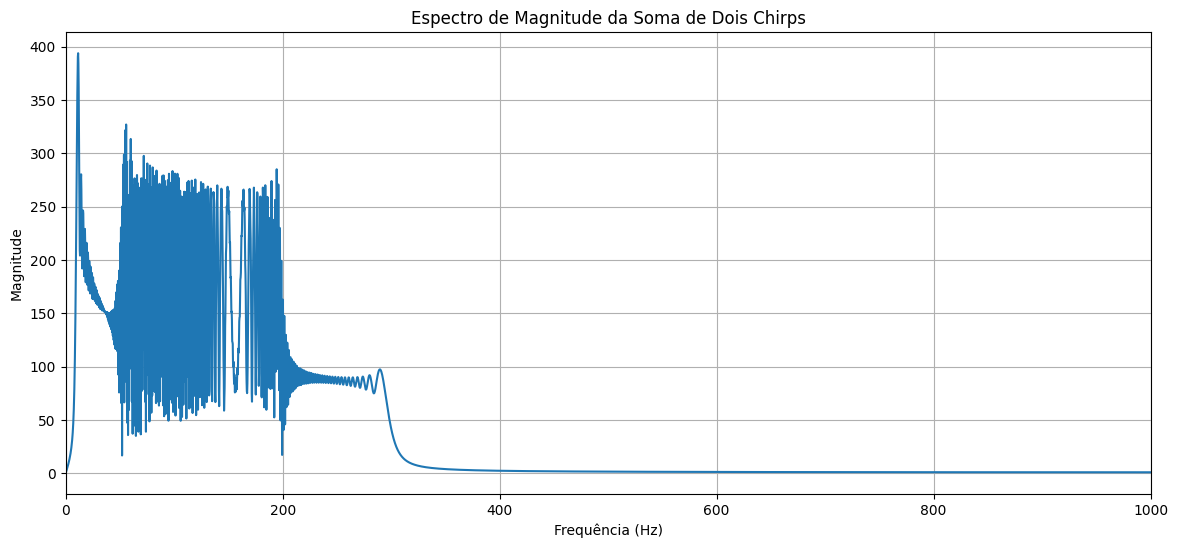

In [ ]:
# 4. Realizar a FFT no sinal composto
Y_sum_two_chirps_fft = fft(y_sum_two_chirps)

# 5. Calcular as frequências correspondentes ao output da FFT
x_sum_two_chirps_freq = fftfreq(N_sum, dt_sum)

# 6. Plotar o espectro de magnitude da FFT
plt.figure(figsize=(14, 6))
plt.plot(x_sum_two_chirps_freq[:N_sum // 2], np.abs(Y_sum_two_chirps_fft[:N_sum // 2]))
plt.title('Espectro de Magnitude da Soma de Dois Chirps')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, Fs_sum / 2) # Limitar o eixo x até a frequência de Nyquist
plt.show()

### Exemplo: Sinal FM (Modulação em Frequência) e sua Representação na Frequência

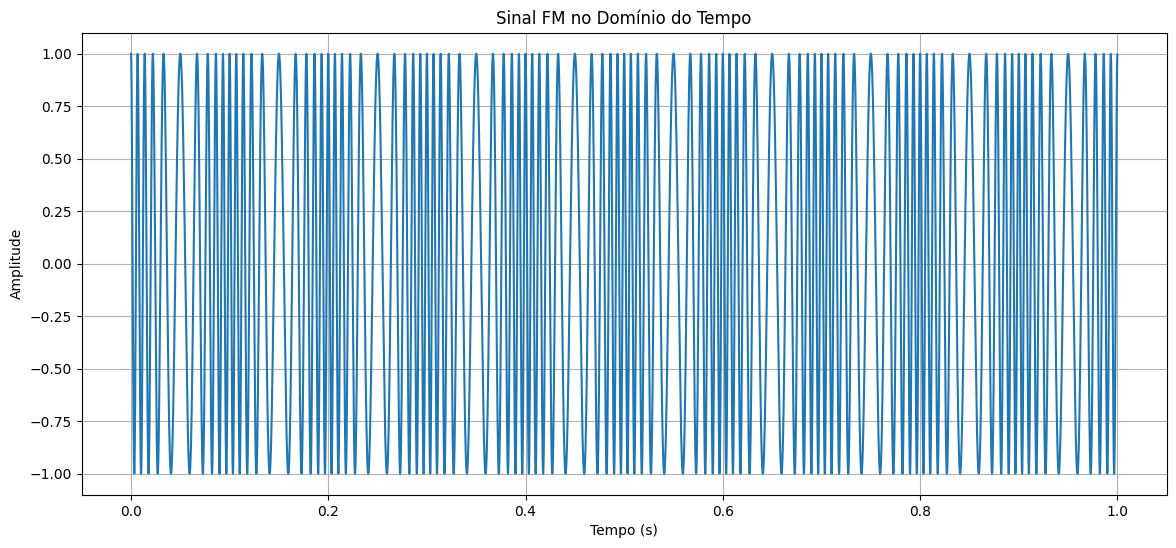

In [ ]:
# 1. Definir parâmetros para o sinal FM
Fs_fm = 10000   # Frequência de amostragem em Hz
T_fm = 1        # Duração total do sinal em segundos
N_fm = int(Fs_fm * T_fm) # Número total de amostras

t_fm = np.linspace(0, T_fm, N_fm, endpoint=False) # Vetor de tempo
dt_fm = t_fm[1] - t_fm[0]

# Parâmetros do sinal FM
fc = 100    # Frequência da portadora (carrier frequency) em Hz
fm = 10     # Frequência da mensagem (message frequency) em Hz
beta = 5    # Índice de modulação (modulation index)

# 2. Gerar o sinal FM
y_fm = np.cos(2 * np.pi * fc * t_fm + beta * np.sin(2 * np.pi * fm * t_fm))

# Plotar o sinal FM no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_fm, y_fm)
plt.title('Sinal FM no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

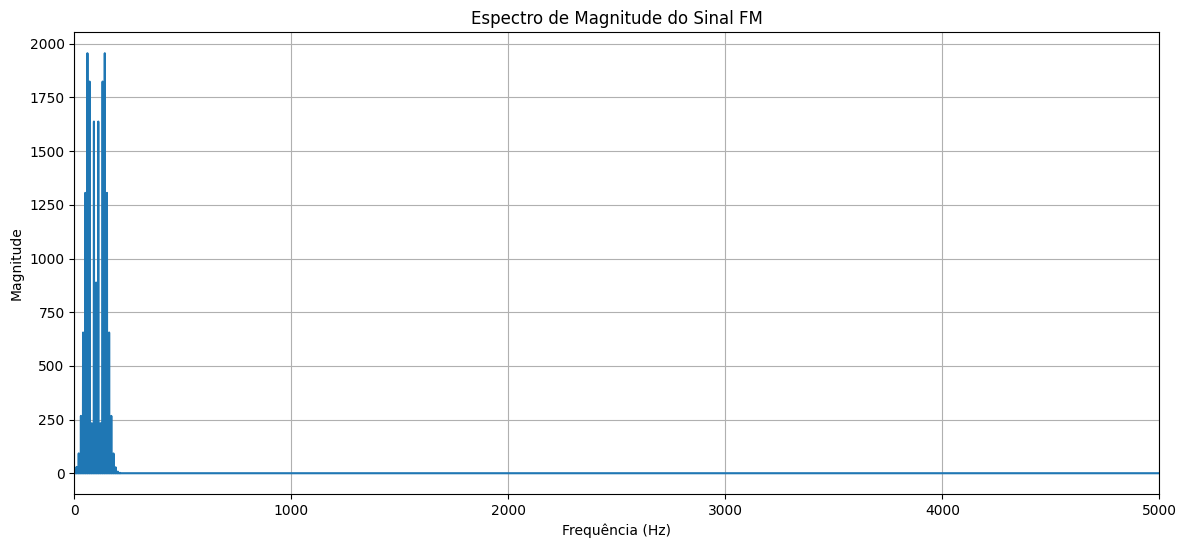

In [ ]:
# 3. Realizar a FFT no sinal FM
Y_fm_fft = fft(y_fm)

# 4. Calcular as frequências correspondentes ao output da FFT
x_fm_freq = fftfreq(N_fm, dt_fm)

# 5. Plotar o espectro de magnitude da FFT
plt.figure(figsize=(14, 6))
plt.plot(x_fm_freq[:N_fm // 2], np.abs(Y_fm_fft[:N_fm // 2]))
plt.title('Espectro de Magnitude do Sinal FM')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, Fs_fm / 2) # Limitar o eixo x até a frequência de Nyquist
plt.show()

### Exemplo: Sinal AM (Modulação em Amplitude) e sua Representação na Frequência

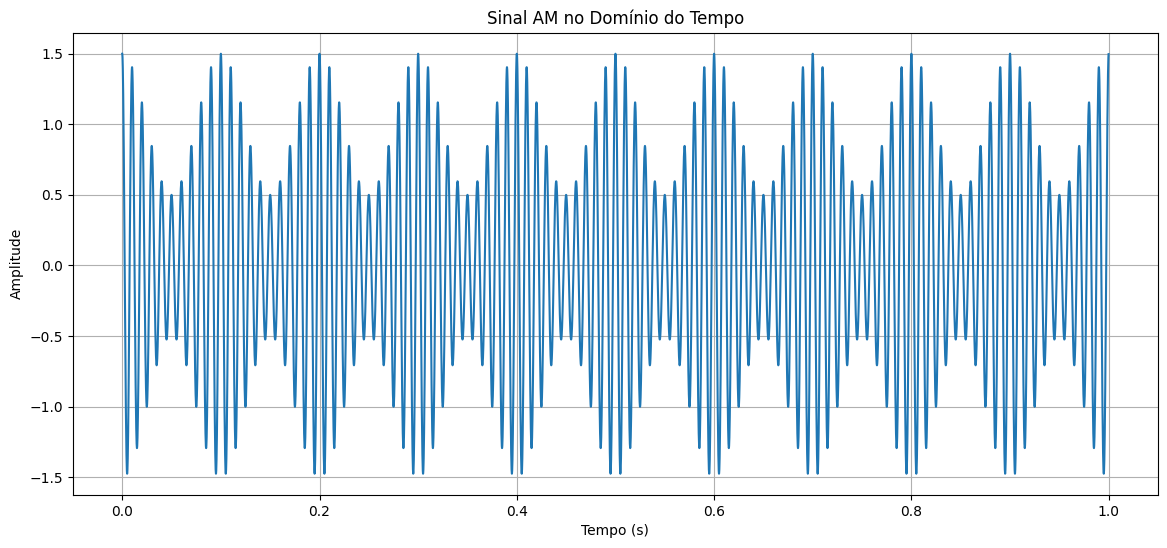

In [ ]:
# 1. Definir parâmetros para o sinal AM
Fs_am = 10000   # Frequência de amostragem em Hz
T_am = 1        # Duração total do sinal em segundos
N_am = int(Fs_am * T_am) # Número total de amostras

t_am = np.linspace(0, T_am, N_am, endpoint=False) # Vetor de tempo
dt_am = t_am[1] - t_am[0]

# Parâmetros do sinal AM
Ac = 1.0    # Amplitude da portadora
fc_am = 100   # Frequência da portadora em Hz
Am = 0.5    # Amplitude da mensagem
fm_am = 10    # Frequência da mensagem em Hz

# 2. Gerar o sinal AM
y_am = Ac * (1 + (Am/Ac) * np.cos(2 * np.pi * fm_am * t_am)) * np.cos(2 * np.pi * fc_am * t_am)

# Plotar o sinal AM no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_am, y_am)
plt.title('Sinal AM no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

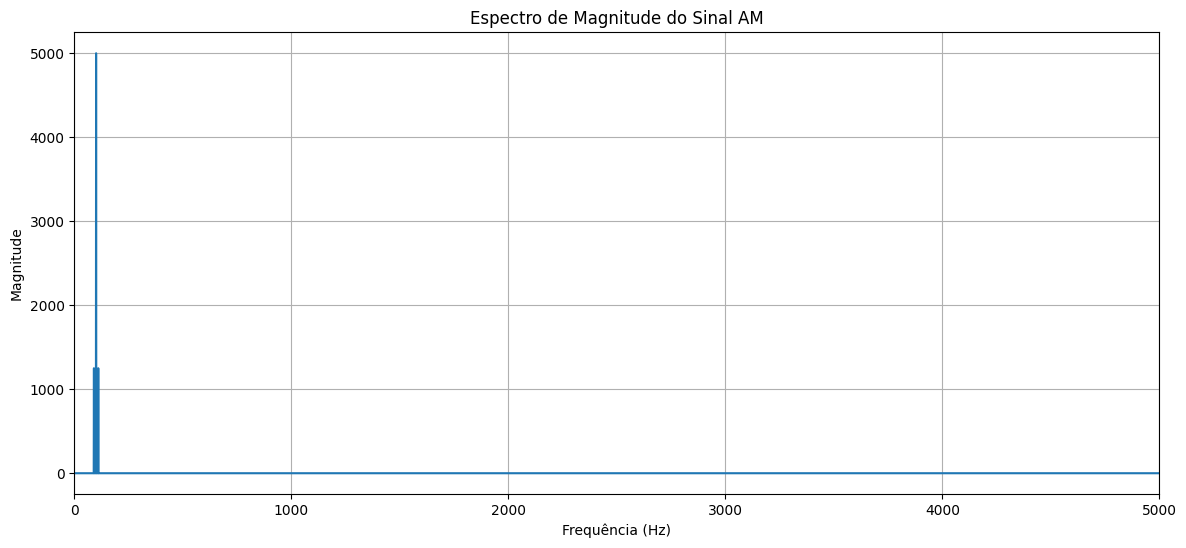

In [ ]:
# 3. Realizar a FFT no sinal AM
Y_am_fft = fft(y_am)

# 4. Calcular as frequências correspondentes ao output da FFT
x_am_freq = fftfreq(N_am, dt_am)

# 5. Plotar o espectro de magnitude da FFT
plt.figure(figsize=(14, 6))
plt.plot(x_am_freq[:N_am // 2], np.abs(Y_am_fft[:N_am // 2]))
plt.title('Espectro de Magnitude do Sinal AM')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, Fs_am / 2) # Limitar o eixo x até a frequência de Nyquist
plt.show()

### Exemplo: Gerar e Tocar o Som de um Sinal Chirp

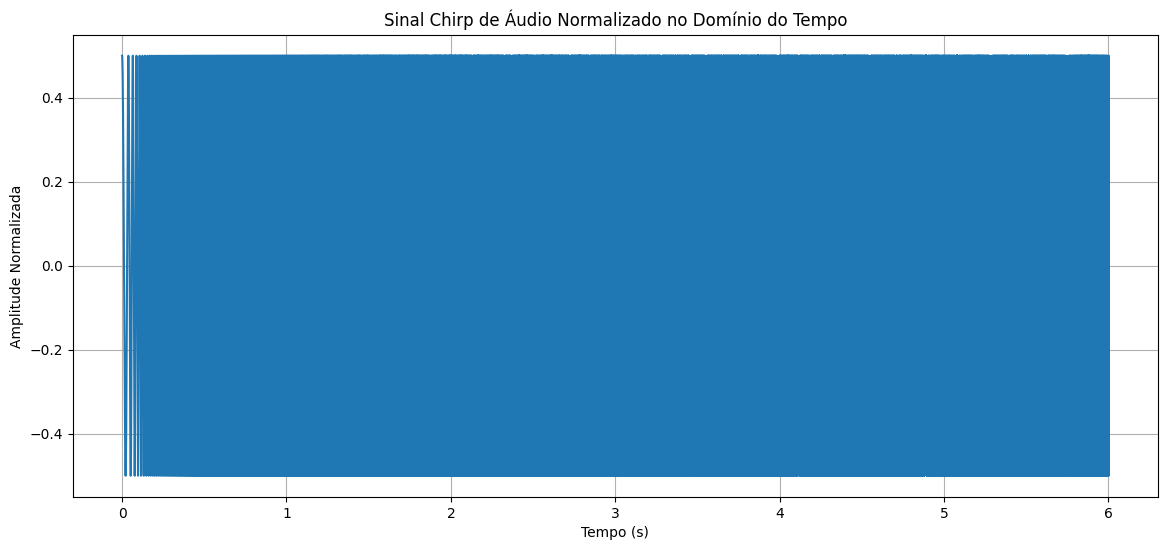

Tocando o som do chirp...


In [ ]:
from IPython.display import Audio
from scipy.signal import chirp

# 1. Definir parâmetros para o sinal chirp de áudio
Fs_audio = 44100  # Frequência de amostragem para áudio (Hz)
T_audio = 6     # Duração total do sinal de áudio (segundos)
f0_audio = 20    # Frequência inicial (Hz)
f1_audio = 2000  # Frequência final (Hz)

N_audio = int(Fs_audio * T_audio) # Número total de amostras
t_audio = np.linspace(0, T_audio, N_audio, endpoint=False) # Vetor de tempo

# 2. Gerar o sinal chirp linear
y_audio_chirp = chirp(t_audio, f0=f0_audio, f1=f1_audio, t1=T_audio, method='linear')

# Normalizar o sinal para evitar clipping de áudio (entre -1 e 1)
y_audio_chirp_normalized = 0.5 * y_audio_chirp / np.max(np.abs(y_audio_chirp))

# Plotar o sinal de áudio chirp no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_audio, y_audio_chirp_normalized)
plt.title('Sinal Chirp de Áudio Normalizado no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude Normalizada')
plt.grid(True)
plt.show()

# Tocar o som do chirp
print('Tocando o som do chirp...')
Audio(y_audio_chirp_normalized, rate=Fs_audio)

### Exemplo: Gerar e Tocar o Som de uma Soma de Três Ondas Senoidais

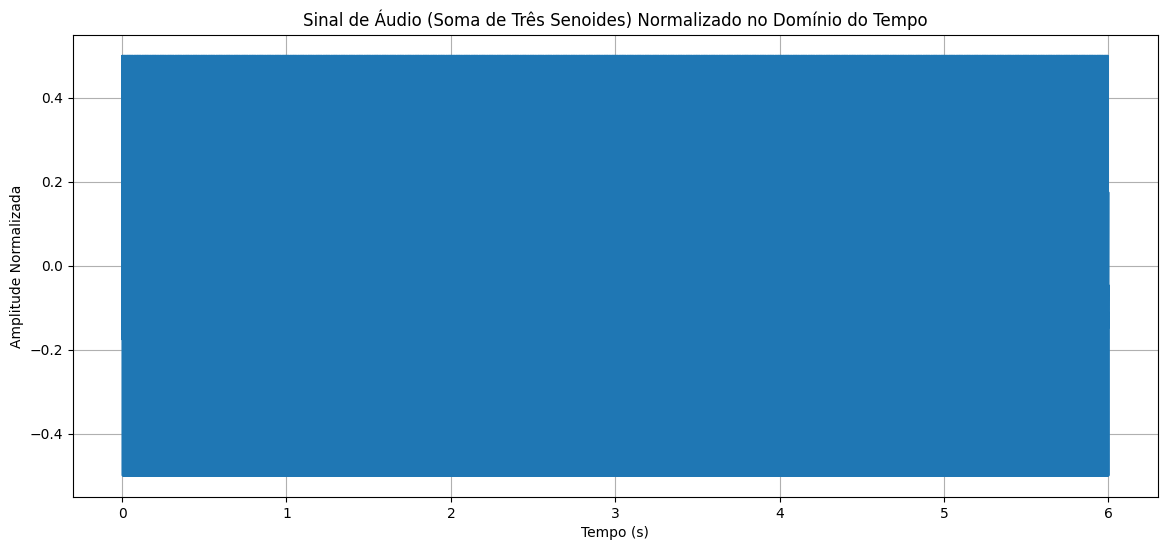

Tocando o som da soma de três senoides...


In [ ]:
from IPython.display import Audio

# 1. Definir parâmetros para o sinal de áudio
Fs_sines_audio = 44100  # Frequência de amostragem para áudio (Hz)
T_sines_audio = 6       # Duração total do sinal de áudio (segundos)
N_sines_audio = int(Fs_sines_audio * T_sines_audio) # Número total de amostras

t_sines_audio = np.linspace(0, T_sines_audio, N_sines_audio, endpoint=False) # Vetor de tempo

# 2. Definir frequências e amplitudes para as três ondas senoidais
f_s1 = 440   # Frequência da primeira senoide (A4)
f_s2 = 660   # Frequência da segunda senoide (E5)
f_s3 = 880   # Frequência da terceira senoide (A5)

A_s1 = 1.0   # Amplitude da primeira senoide
A_s2 = 0.7   # Amplitude da segunda senoide
A_s3 = 0.5   # Amplitude da terceira senoide

# 3. Gerar as três ondas senoidais
sine_audio1 = A_s1 * np.sin(2 * np.pi * f_s1 * t_sines_audio)
sine_audio2 = A_s2 * np.sin(2 * np.pi * f_s2 * t_sines_audio)
sine_audio3 = A_s3 * np.sin(2 * np.pi * f_s3 * t_sines_audio)

# 4. Somar as três ondas senoidais
y_sum_sines_audio = sine_audio1 + sine_audio2 + sine_audio3

# 5. Normalizar o sinal para evitar clipping de áudio (entre -1 e 1)
y_sum_sines_audio_normalized = 0.5 * y_sum_sines_audio / np.max(np.abs(y_sum_sines_audio))

# Plotar o sinal de áudio resultante no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_sines_audio, y_sum_sines_audio_normalized)
plt.title('Sinal de Áudio (Soma de Três Senoides) Normalizado no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude Normalizada')
plt.grid(True)
plt.show()

# Tocar o som
print('Tocando o som da soma de três senoides...')
Audio(y_sum_sines_audio_normalized, rate=Fs_sines_audio)

### Exemplo: Gerar e Tocar um Sinal Senoidal de 120 Hz

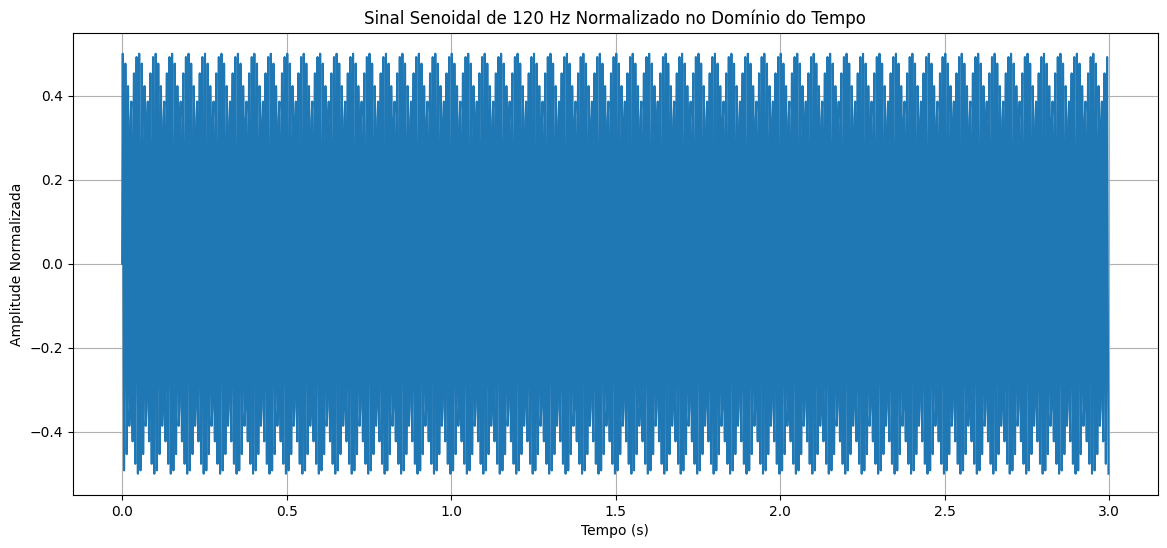

Tocando o som do seno de 120 Hz...


In [ ]:
# 1. Definir parâmetros para o sinal de áudio senoidal
Fs_sine_120 = 500 # Frequência de amostragem para áudio (Hz)
T_sine_120 = 3      # Duração total do sinal de áudio (segundos)
f_sine = 120       # Frequência do seno em Hz

N_sine_120 = int(Fs_sine_120 * T_sine_120) # Número total de amostras
t_sine_120 = np.linspace(0, T_sine_120, N_sine_120, endpoint=False) # Vetor de tempo

# 2. Gerar o sinal senoidal
y_sine_120 = np.sin(2 * np.pi * f_sine * t_sine_120)

# 3. Normalizar o sinal para evitar clipping de áudio (entre -1 e 1)
y_sine_120_normalized = 0.5 * y_sine_120 / np.max(np.abs(y_sine_120))

# Plotar o sinal senoidal no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_sine_120, y_sine_120_normalized)
plt.title(f'Sinal Senoidal de {f_sine} Hz Normalizado no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude Normalizada')
plt.grid(True)
plt.show()

# Tocar o som do seno
print(f'Tocando o som do seno de {f_sine} Hz...')
Audio(y_sine_120_normalized, rate=Fs_sine_120)

### Exemplo: Gerar e Tocar um Sinal Senoidal de 120 Hz com Ruído Branco

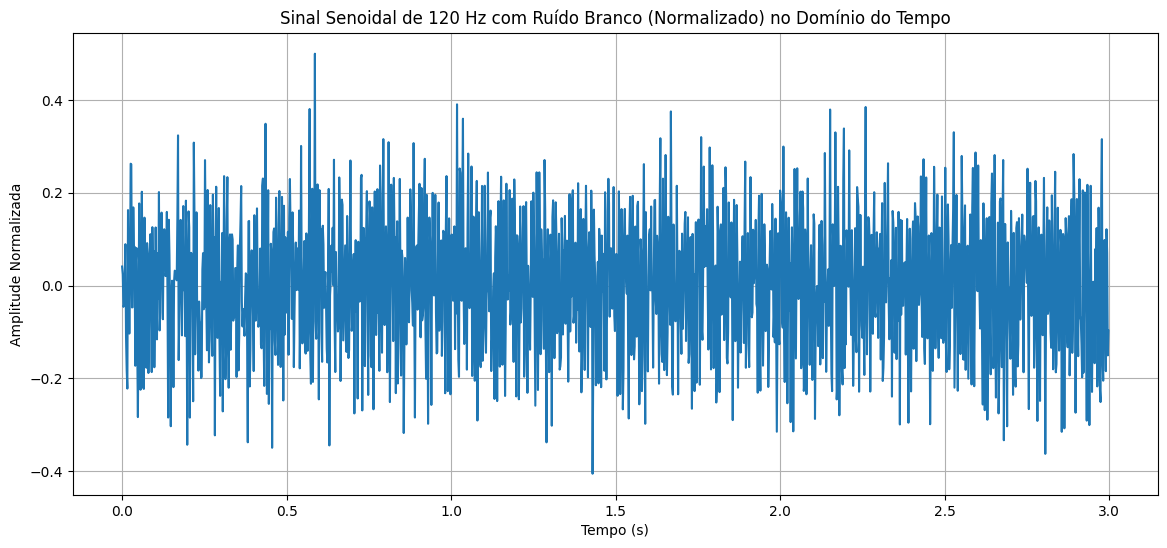

Tocando o som do seno de 120 Hz com ruído branco...


In [ ]:
# 1. Parâmetros do sinal senoidal (reutilizar do exemplo anterior)
Fs_sine_noise = Fs_sine_120
T_sine_noise = T_sine_120
f_sine_noise = f_sine
N_sine_noise = N_sine_120
t_sine_noise = t_sine_120

# 2. Gerar o sinal senoidal
y_sine_noise = np.sin(2 * np.pi * f_sine_noise * t_sine_noise)

# 3. Gerar ruído branco
# O ruído branco é gerado com a mesma forma do sinal e uma amplitude menor
noise_amplitude = 0.6 # Ajuste a amplitude do ruído conforme necessário
white_noise = noise_amplitude * np.random.randn(N_sine_noise)

# 4. Somar o sinal senoidal e o ruído branco
y_sine_plus_noise = y_sine_noise + white_noise

# 5. Normalizar o sinal para evitar clipping de áudio (entre -1 e 1)
y_sine_plus_noise_normalized = 0.5 * y_sine_plus_noise / np.max(np.abs(y_sine_plus_noise))

# Plotar o sinal senoidal com ruído no domínio do tempo
plt.figure(figsize=(14, 6))
plt.plot(t_sine_noise, y_sine_plus_noise_normalized)
plt.title(f'Sinal Senoidal de {f_sine_noise} Hz com Ruído Branco (Normalizado) no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude Normalizada')
plt.grid(True)
plt.show()

# Tocar o som do seno com ruído
print(f'Tocando o som do seno de {f_sine_noise} Hz com ruído branco...')
Audio(y_sine_plus_noise_normalized, rate=Fs_sine_noise)

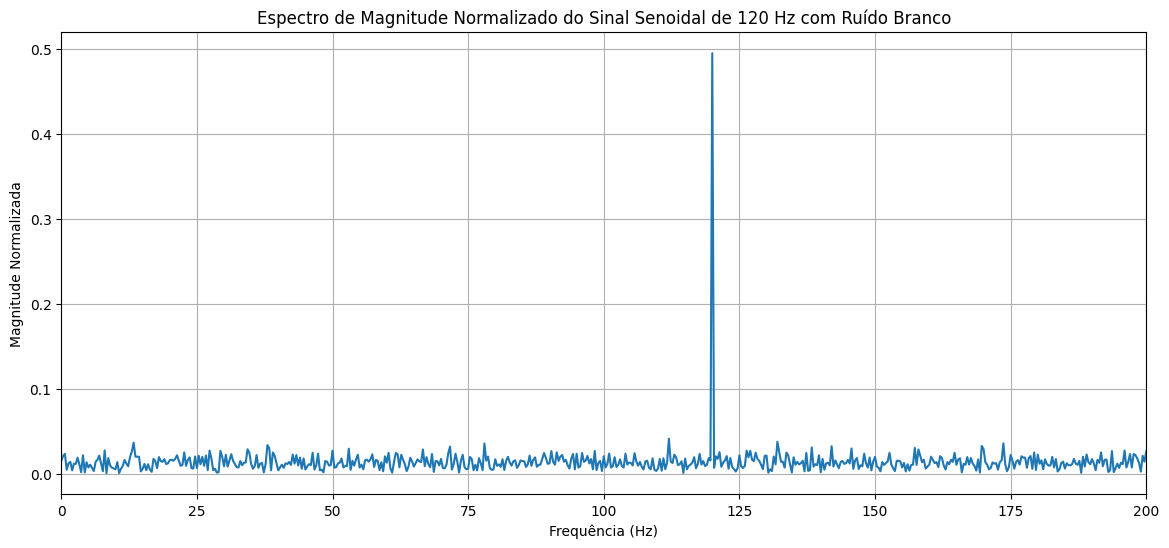

In [ ]:
# 1. Realizar a FFT no sinal com ruído
Y_sine_plus_noise_fft = fft(y_sine_plus_noise)

# 2. Calcular as frequências correspondentes ao output da FFT
dt_sine_noise = t_sine_noise[1] - t_sine_noise[0]
x_sine_plus_noise_freq = fftfreq(N_sine_noise, dt_sine_noise)

# 3. Plotar o espectro de magnitude da FFT
plt.figure(figsize=(14, 6))
plt.plot(x_sine_plus_noise_freq[:N_sine_noise // 2], np.abs(Y_sine_plus_noise_fft[:N_sine_noise // 2]) / N_sine_noise)
plt.title(f'Espectro de Magnitude Normalizado do Sinal Senoidal de {f_sine_noise} Hz com Ruído Branco')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude Normalizada')
plt.grid(True)
plt.xlim(0, 200) # Limitar o eixo x até a frequência de Nyquist
plt.show()